# EXPLORATORY DATA ANALYSIS (EDA)

## 1. IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

#Automcompletar rápido
%config IPCompleter.greedy=True

#Formato sin notación científica
pd.options.display.float_format = '{:15.2f}'.format 

## 2. IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
ruta_proyecto = 'C:/Users/Oscar/OneDrive - FM4/Escritorio/EVOLVE/Data Science/Proyecto-Master-DataScience-Evolve-OscarFraile'

Nombres de los ficheros de datos.

In [3]:
nombre_cat = 'cat_resultado_calidad.pickle'
nombre_num = 'num_resultado_calidad.pickle'

Cargar los datos.

In [4]:
cat = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_cat)
num = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_num)

## 3. EDA CATEGÓRICAS

### 3.1. Análisis estadístico

In [5]:
cat.columns.to_list()

['name',
 'host_response_time',
 'host_is_superhost',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'property_type',
 'room_type',
 'amenities',
 'has_availability',
 'license',
 'instant_bookable',
 'neighbourhood_group',
 'host_since',
 'first_review',
 'last_review',
 'bedrooms_disc',
 'accommodates_disc',
 'beds_disc',
 'number_of_reviews_disc']

In [6]:
incluir_cat = cat.columns.to_list()

#Eliminamos las columnas que estén en la siguiente lista
for i in sorted([0, 6, 8, 13, 14, 15], reverse=True):
    del incluir_cat[i]

In [7]:
def frecuencias_cat(cat):
    # Asegúrate de que todas las columnas son de tipo 'str' para evitar problemas de comparación
    cat = cat[incluir_cat]
    
    resultado = cat.apply(lambda x: x.value_counts(normalize = True))\
                .T.stack()\
                .to_frame().reset_index()\
                .rename(columns={'level_0':'Variable','level_1':'Valor',0: "Frecuencia"})\
                .sort_values(by = ['Variable','Frecuencia'])
    return resultado

In [8]:
cat[incluir_cat].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18111 entries, 30959 to 1308864880309321118
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   host_response_time      18111 non-null  object
 1   host_is_superhost       18111 non-null  object
 2   host_verifications      18111 non-null  object
 3   host_has_profile_pic    18111 non-null  object
 4   host_identity_verified  18111 non-null  object
 5   room_type               18111 non-null  object
 6   has_availability        18111 non-null  object
 7   license                 18111 non-null  object
 8   instant_bookable        18111 non-null  object
 9   neighbourhood_group     18111 non-null  object
 10  bedrooms_disc           18111 non-null  object
 11  accommodates_disc       18111 non-null  object
 12  beds_disc               18111 non-null  object
 13  number_of_reviews_disc  18111 non-null  object
dtypes: object(14)
memory usage: 2.1+ MB


In [9]:
pd.set_option('display.max_rows', None)

frecuencias_cat(cat[incluir_cat])
#Aparecerá una lista de todas las variables con su frecuencia asociada

,Variable,Valor,Frecuencia
54,accommodates_disc,4-16,0.17
53,accommodates_disc,4,0.24
52,accommodates_disc,0-3,0.59
51,bedrooms_disc,04_Cuatro o mas,0.03
50,bedrooms_disc,03_Tres,0.07
47,bedrooms_disc,00_Estudio,0.15
49,bedrooms_disc,02_Dos,0.21
48,bedrooms_disc,01_Una,0.54
57,beds_disc,3-19,0.09
56,beds_disc,3,0.41


### 3.2. Análisis gráfico

In [10]:
def graficos_eda_categoricos(cat):
  
    # Filtrar solo columnas numéricas seleccionadas en incluir_num
    cat = cat[incluir_cat]

    # Verificar si hay columnas numéricas
    if cat.shape[1] == 0:
        print("No hay columnas categóricas para graficar.")
        return    
    #Calculamos el número de filas que necesitamos
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

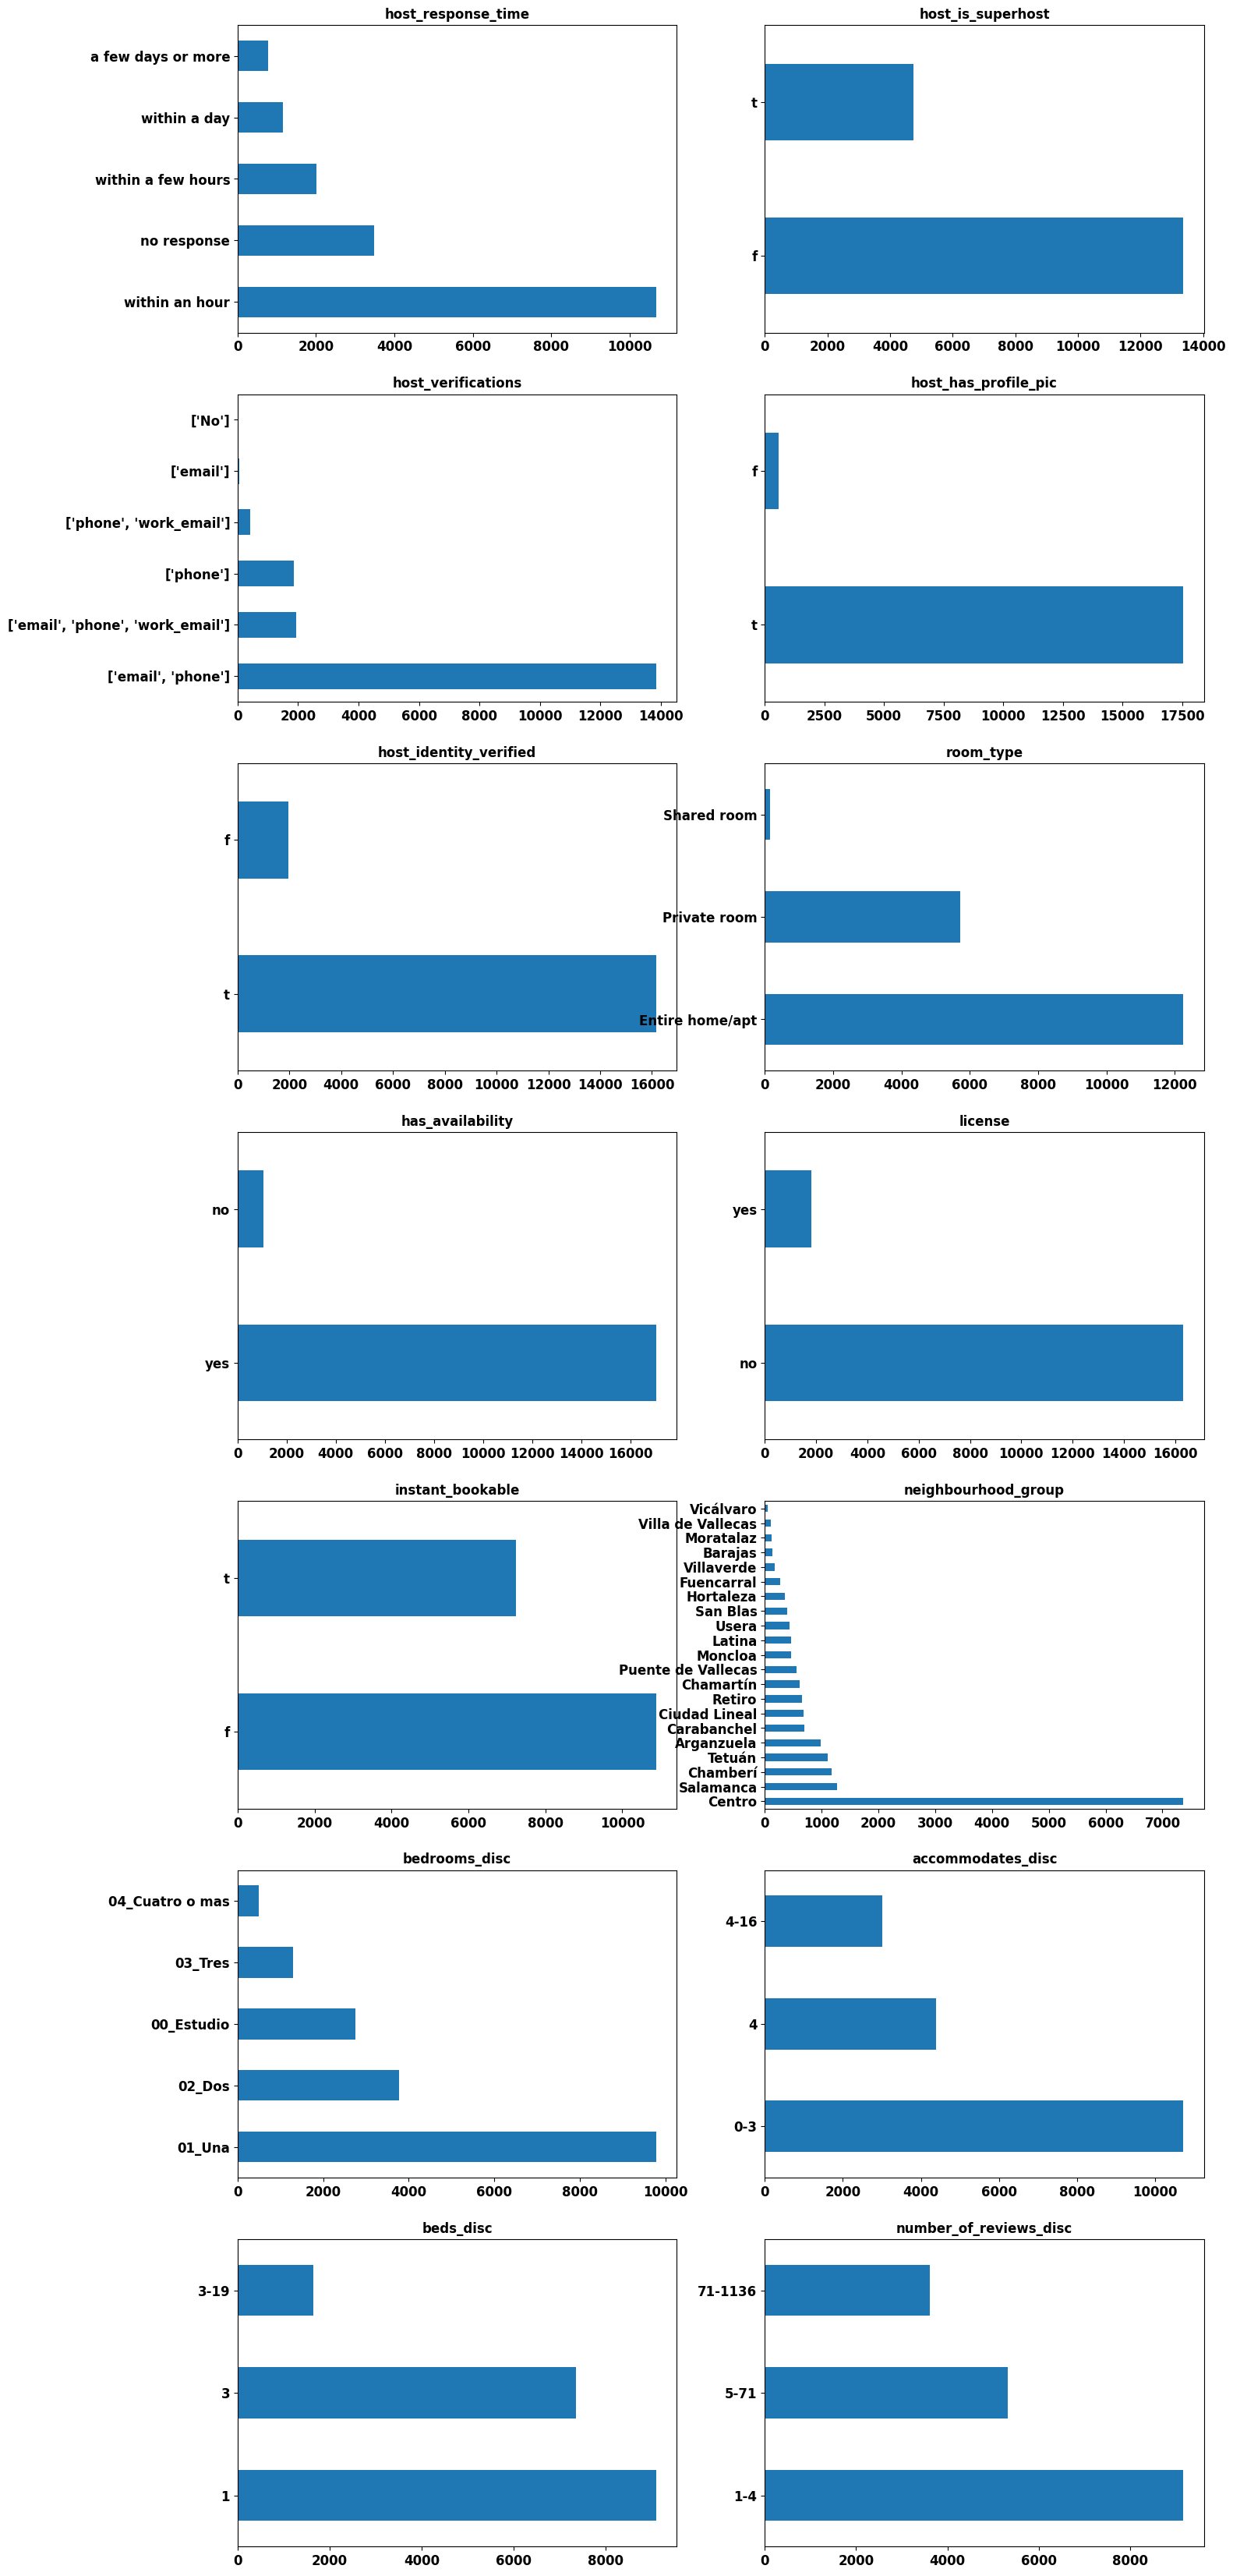

In [11]:
graficos_eda_categoricos(cat)

## 4. EDA NUMÉRICAS

### 4.1. Análisis estadístico

In [12]:
incluir_num = num.columns.to_list()

#Eliminamos las columnas que estén en la siguiente lista
for i in sorted([0], reverse=True):
    del incluir_num[i]

In [13]:
def estadisticos_cont(num):
    #Calculamos describe
    estadisticos = num.describe().T
    #Añadimos la mediana
    estadisticos['median'] = num.median()
    #Reordenamos para que la mediana esté al lado de la media
    estadisticos = estadisticos.iloc[:,[0,1,8,2,3,4,5,6,7]]
    #Lo devolvemos
    return(estadisticos)

In [14]:
num[incluir_num].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18111 entries, 30959 to 1308864880309321118
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_id                                       18111 non-null  int64  
 1   host_response_rate                            18111 non-null  float64
 2   host_acceptance_rate                          18111 non-null  float64
 3   host_listings_count                           18111 non-null  float64
 4   host_total_listings_count                     18111 non-null  float64
 5   latitude                                      18111 non-null  float64
 6   longitude                                     18111 non-null  float64
 7   accommodates                                  18111 non-null  int64  
 8   bathrooms                                     18111 non-null  float64
 9   bedrooms                                   

In [15]:
pd.set_option('display.max_rows', None)

estadisticos_cont(num[incluir_num])
#Aparecerá una lista de todas las variables con su frecuencia asociada

,count,mean,median,std,min,25%,50%,75%,max
host_id,18111.00,247326137.81,206493136.00,203658672.72,7952.00,47554470.00,206493136.00,443065412.00,666283584.00
host_response_rate,18111.00,74.54,100.00,40.81,0.00,64.00,100.00,100.00,100.00
host_acceptance_rate,18111.00,84.70,97.00,24.40,0.00,82.00,97.00,100.00,100.00
host_listings_count,18111.00,50.56,3.00,133.81,1.00,1.00,3.00,24.00,3251.00
host_total_listings_count,18111.00,61.38,5.00,187.19,1.00,2.00,5.00,31.00,7970.00
latitude,18111.00,40.42,40.42,0.02,40.33,40.41,40.42,40.43,40.54
longitude,18111.00,-3.69,-3.70,0.03,-3.83,-3.71,-3.70,-3.68,-3.55
accommodates,18111.00,3.17,3.00,1.91,1.00,2.00,3.00,4.00,16.00
bathrooms,18111.00,1.28,1.00,0.61,0.00,1.00,1.00,1.50,15.00
bedrooms,18111.00,1.30,1.00,0.99,0.00,1.00,1.00,2.00,14.00


### 4.2. Análisis gráfico

In [16]:
def graficos_eda_continuas(num):
    
    # Filtrar solo columnas numéricas seleccionadas en incluir_num
    num = num[incluir_num]

    # Verificar si hay columnas numéricas
    if num.shape[1] == 0:
        print("No hay columnas numéricas para graficar.")
        return
    
    #Calculamos el número de fila que necesitamos
    from math import ceil
    filas = ceil(num.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(num):
        num[variable].plot.density(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

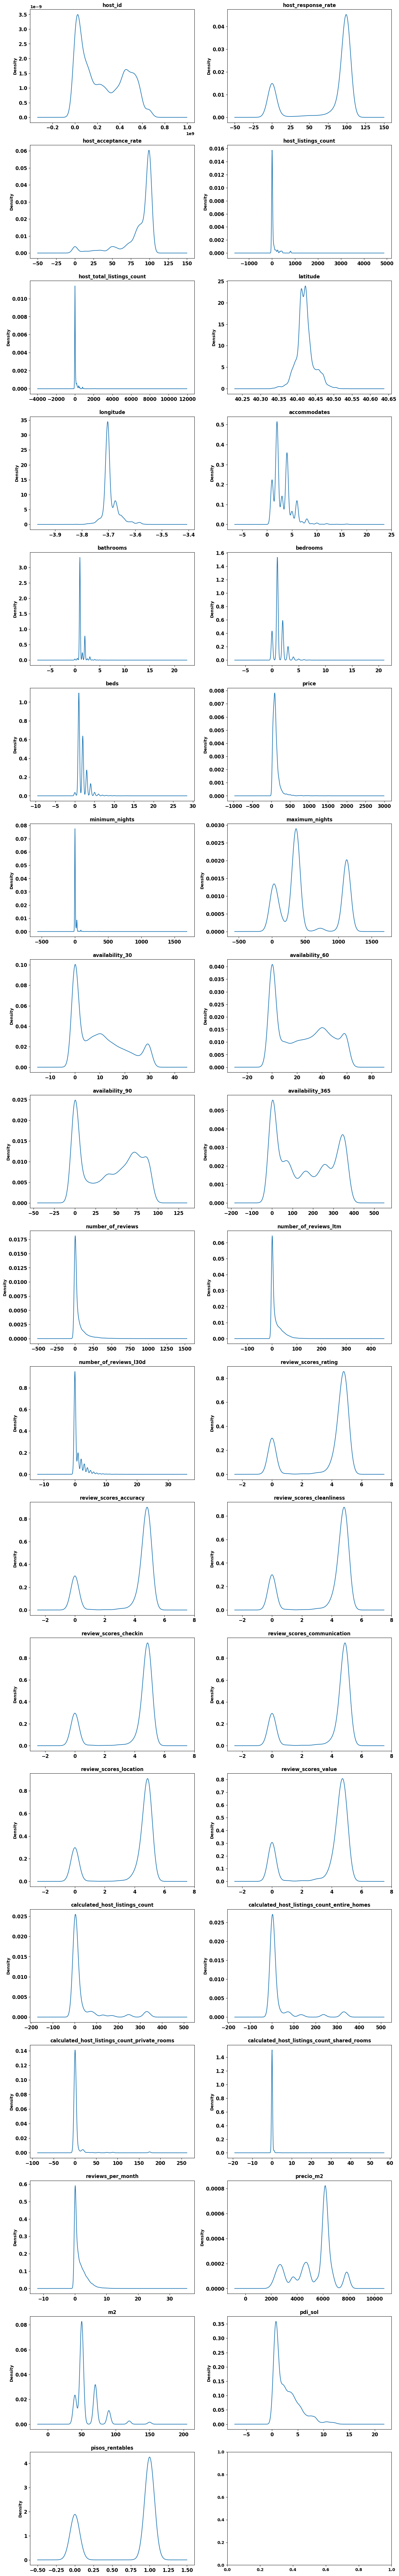

In [17]:
graficos_eda_continuas(num)

## 5. GUARDAR DATASETS TRAS CALIDAD DE DATOS

Guardamos los avances en cat y num con un sufijo para poder guardar o recuperar avances del proyecto.

En formato pickle para no perder las modificaciones de metadatos.

In [18]:
#Definir los nombres de los archivos
ruta_cat = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'cat_resultado_eda.pickle'
ruta_num = ruta_proyecto + '/02_Datos/03_Trabajo/' + 'num_resultado_eda.pickle'

In [19]:
#Guardar los archivos
cat.to_pickle(ruta_cat)
num.to_pickle(ruta_num)